# Transformers from scratch · Part 1: translating German to English

This is the standard first experiment with **"Attention Is All You Need"** (Vaswani et al., 2017). The recipe is the same as training a CNN on MNIST: take one standard dataset and one standard model, train it, and measure it.

| | |
|---|---|
| **Task** | translate German sentences into English |
| **Data** | Multi30k: 29,000 German–English training pairs (short image captions), 1,014 for validation, 1,000 for testing |
| **Model** | the paper's encoder–decoder Transformer, written from scratch (3 layers instead of 6, so it trains in minutes) |
| **Metric** | BLEU on the test set |

**Steps**

1. Data
2. Tokens: turning text into numbers
3. Batches and padding
4. The model, one piece at a time: embeddings → positional encoding → attention (queries, keys, values) → masks → multi-head attention → feed-forward, residual connections and LayerNorm → encoder layer → decoder layer → the full model
5. Training: teacher forcing, the loss, the optimizer
6. Translating new sentences: greedy decoding
7. Measuring quality: BLEU
8. Looking inside: attention maps

Run the cells in order. Every idea comes with a small check (a printed shape, a number or a plot) so you can see it working before moving on.

**Notation:** `B` = sentences in a batch, `S` = source length and `T` = target length (in tokens), `d_model` = size of each token's vector, `h` = number of attention heads.

In [1]:
# Settings. The defaults train in a few minutes on an RTX 4090.
EPOCHS = 15        # passes over the training data
BATCH_SIZE = 128   # sentence pairs per training step
D_MODEL = 256      # size of every token vector (paper: 512)
N_HEADS = 8        # attention heads (paper: 8)
N_LAYERS = 3       # encoder layers, and also decoder layers (paper: 6)
D_FF = 1024        # hidden size of the feed-forward network, 4 x D_MODEL (paper: 2048)
DROPOUT = 0.1      # (paper: 0.1)
LR = 5e-4          # learning rate after warm-up

## 0 · Setup

In [2]:
import gzip, math, random, re, time, urllib.request
from collections import Counter
from pathlib import Path

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import sacrebleu                      # the standard BLEU implementation: pip install sacrebleu

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
random.seed(0)
torch.manual_seed(0)
print("PyTorch", torch.__version__, "| device:", device)

Matplotlib is building the font cache; this may take a moment.


PyTorch 2.14.1 | device: mps


## 1 · Data

Multi30k (Elliott et al., 2016) is to translation what MNIST is to image classification: small, clean and widely used. The paper trained on WMT 2014 (4.5 million sentence pairs, 12 hours on 8 GPUs), but the ideas are exactly the same.

The files come from the dataset's GitHub page and are saved in `data/multi30k/`.

In [3]:
URL = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw"
DATA = Path("data/multi30k")
DATA.mkdir(parents=True, exist_ok=True)

def load(split):
    for lang in ("de", "en"):
        path = DATA / f"{split}.{lang}.gz"
        if not path.exists():
            urllib.request.urlretrieve(f"{URL}/{split}.{lang}.gz", path)
    with gzip.open(DATA / f"{split}.de.gz", "rt", encoding="utf-8") as de, \
         gzip.open(DATA / f"{split}.en.gz", "rt", encoding="utf-8") as en:
        return [(d.strip(), e.strip()) for d, e in zip(de, en)]       # list of (German, English) pairs

train, val, test = load("train"), load("val"), load("test_2016_flickr")
print(f"train {len(train):,} | validation {len(val):,} | test {len(test):,} sentence pairs\n")
for de, en in train[:3]:
    print("DE:", de)
    print("EN:", en, "\n")

train 29,000 | validation 1,014 | test 1,000 sentence pairs

DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
EN: Two young, White males are outside near many bushes. 

DE: Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.
EN: Several men in hard hats are operating a giant pulley system. 

DE: Ein kleines Mädchen klettert in ein Spielhaus aus Holz.
EN: A little girl climbing into a wooden playhouse. 



## 2 · Tokens: turning text into numbers

A neural network only works with numbers. **Tokenization** cuts text into pieces called *tokens*, and a **vocabulary** gives every token an id (an integer).

We keep it simple: lowercase everything, and split into words and punctuation marks. (Real systems use *subword* tokenizers such as BPE, which split rare words into common pieces; Part 3 of this series uses one.)

Four **special tokens**:

| token | id | meaning |
|---|---|---|
| `<pad>` | 0 | filler, to make all sentences in a batch the same length |
| `<s>` | 1 | start of a sentence |
| `</s>` | 2 | end of a sentence: the model learns to produce it when it's done |
| `<unk>` | 3 | "unknown": any word that isn't in the vocabulary |

Words seen fewer than 2 times in the training data are left out of the vocabulary, so they become `<unk>`. Each language gets its own vocabulary.

In [4]:
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())     # words, and each punctuation mark on its own

print(tokenize("Zwei junge Männer spielen Fußball."))

['zwei', 'junge', 'männer', 'spielen', 'fußball', '.']


In [5]:
SPECIALS = ["<pad>", "<s>", "</s>", "<unk>"]
PAD, BOS, EOS, UNK = 0, 1, 2, 3

class Vocab:
    def __init__(self, sentences, min_freq=2):
        counts = Counter(token for s in sentences for token in tokenize(s))
        self.itos = SPECIALS + sorted(t for t, c in counts.items() if c >= min_freq)   # id -> token
        self.stoi = {t: i for i, t in enumerate(self.itos)}                              # token -> id

    def __len__(self):
        return len(self.itos)

    def encode(self, text):             # "a dog ." -> [1, 13, 789, 9, 2]
        return [BOS] + [self.stoi.get(t, UNK) for t in tokenize(text)] + [EOS]

    def decode(self, ids):              # [1, 13, 789, 9, 2] -> "a dog ."
        return " ".join(self.itos[i] for i in ids if i not in (PAD, BOS, EOS))

de_vocab = Vocab(de for de, _ in train)
en_vocab = Vocab(en for _, en in train)
print(f"vocabulary size: German {len(de_vocab):,} | English {len(en_vocab):,}\n")

ids = de_vocab.encode(train[0][0])
print(train[0][0])
print("->", ids)
print("->", de_vocab.decode(ids))

val_ids = [i for de, _ in val for i in de_vocab.encode(de)]
print(f"\nshare of <unk> in the German validation text: {val_ids.count(UNK) / len(val_ids):.1%}")

vocabulary size: German 7,882 | English 5,898

Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
-> [1, 7774, 3453, 7463, 4551, 5999, 3310, 2190, 3316, 1419, 4708, 7202, 1251, 14, 2]
-> zwei junge weiße männer sind im freien in der nähe vieler büsche .

share of <unk> in the German validation text: 3.6%


## 3 · Batches and padding

We train on 128 sentence pairs at a time. Sentences have different lengths, but a tensor has to be rectangular, so the shorter sentences are filled up with `<pad>` (id 0). The model will be told to ignore the padding (section 4.4).

In [6]:
def collate(pairs):
    # A list of (German, English) pairs -> two padded tensors of token ids
    src = [torch.tensor(de_vocab.encode(de)) for de, _ in pairs]
    tgt = [torch.tensor(en_vocab.encode(en)) for _, en in pairs]
    return (pad_sequence(src, batch_first=True, padding_value=PAD),     # (B, S)
            pad_sequence(tgt, batch_first=True, padding_value=PAD))     # (B, T)

train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val, batch_size=BATCH_SIZE, collate_fn=collate)

src, tgt = next(iter(train_loader))
print("source batch", tuple(src.shape), "| target batch", tuple(tgt.shape))
print("one target sentence:", tgt[0].tolist())
print(f"{len(train_loader)} batches per epoch")

source batch (128, 33) | target batch (128, 29)
one target sentence: [1, 5252, 2412, 212, 1046, 5550, 5252, 3234, 14, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
227 batches per epoch


## 4 · The model, one piece at a time

```
   German ids (B, S)                                English ids so far (B, T)
         │                                                   │
   embedding + positional encoding                   embedding + positional encoding
         │                                                   │
 ┌───────▼─────────────────┐                     ┌───────────▼───────────────────┐
 │ ENCODER LAYER  (× N)    │                     │ DECODER LAYER  (× N)          │
 │  self-attention         │                     │  masked self-attention        │
 │  add & norm             │                     │  add & norm                   │
 │  feed-forward           │   memory (B, S, d)  │  cross-attention to memory    │
 │  add & norm             │ ──────────────────► │  add & norm                   │
 └─────────────────────────┘                     │  feed-forward                 │
                                                 │  add & norm                   │
                                                 └───────────┬───────────────────┘
                                                             │
                                                  linear → a score for every English word
```

The **encoder** reads the whole German sentence and turns each word into a vector that knows about its context: the *memory*. The **decoder** writes the English sentence one word at a time. At each step it looks at the words it has written so far, and, through cross-attention, at the memory.

### 4.1 Embeddings

An **embedding** is a lookup table with one learned vector (of size `d_model`) per token: token id 37 → row 37 of the table. During training, words that are used in similar ways end up with similar vectors.

The paper multiplies the vectors by $\sqrt{d_\text{model}}$. We start the table with values of size about $1/\sqrt{d_\text{model}}$, so after the multiplication each number is about 1 in size: the same scale as the positional encodings that are added next.

In [7]:
emb = nn.Embedding(len(de_vocab), D_MODEL)
nn.init.normal_(emb.weight, std=D_MODEL ** -0.5)
vectors = emb(src) * math.sqrt(D_MODEL)
print("token ids", tuple(src.shape), "-> vectors", tuple(vectors.shape), f"| typical size of a number: {vectors.std():.2f}")

token ids (128, 33) -> vectors (128, 33, 256) | typical size of a number: 1.03


### 4.2 Positional encoding

Attention (next section) compares every token with every other token, but it has **no sense of order**: shuffle the words, and each word gets exactly the same result. So we add the position to each token's vector, as a pattern of sines and cosines:

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_\text{model}}}\right), \qquad PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_\text{model}}}\right)$$

Each pair of dimensions turns at its own speed: the first dimensions change quickly from one position to the next, the last ones very slowly, like the hands of a clock. Every position gets a unique pattern, and nearby positions get similar patterns.

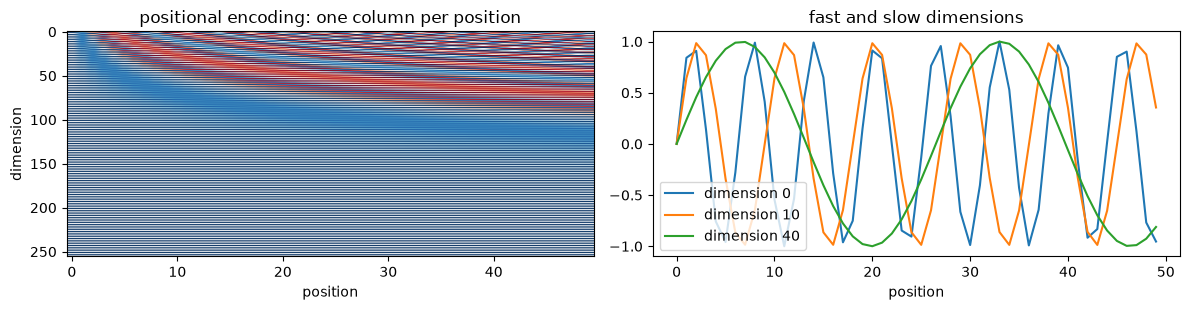

similarity of positions 10 and 11: 0.97 | 10 and 40: 0.56


In [8]:
def positional_encoding(max_len, d_model):
    pos = torch.arange(max_len).unsqueeze(1)                                          # (max_len, 1)
    speed = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))   # (d_model / 2,)
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(pos * speed)      # even dimensions
    pe[:, 1::2] = torch.cos(pos * speed)      # odd dimensions
    return pe                                 # (max_len, d_model)

pe = positional_encoding(100, D_MODEL)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].imshow(pe[:50].T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
axes[0].set(xlabel="position", ylabel="dimension", title="positional encoding: one column per position")
for d in (0, 10, 40):
    axes[1].plot(pe[:50, d], label=f"dimension {d}")
axes[1].set(xlabel="position", title="fast and slow dimensions"); axes[1].legend()
plt.tight_layout(); plt.show()

cos = nn.functional.cosine_similarity
print(f"similarity of positions 10 and 11: {cos(pe[10], pe[11], dim=0):.2f} | 10 and 40: {cos(pe[10], pe[40], dim=0):.2f}")

### 4.3 Attention: queries, keys and values

Attention is a **soft dictionary lookup**. Every token produces three vectors:

- a **query** $q$: what this token is looking for
- a **key** $k$: what this token offers, used to decide whether it matches a query
- a **value** $v$: what this token passes on if it is chosen

For each query, the steps are:

1. **score** it against every key with a dot product: large when the two vectors point the same way
2. **scale** the scores by $1/\sqrt{d_k}$ (explained below)
3. **softmax**: turn the scores into weights that are positive and sum to 1
4. **blend**: the output is the weighted average of the values

All queries at once, as matrices:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

In [9]:
def attention(q, k, v, mask=None):
    # q: (..., T_q, d_k)   k, v: (..., T_k, d_k)   mask: True where attending is allowed
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)       # (..., T_q, T_k): every query against every key
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))   # blocked pairs get weight exactly 0 after softmax
    weights = scores.softmax(dim=-1)                        # each row sums to 1
    return weights @ v, weights                             # (..., T_q, d_k): blends of the values

In [10]:
# A tiny example you can check by hand: 3 tokens with vectors of size 2
q = torch.tensor([[1.0, 0.0],      # token 0 looks for "direction 1"
                  [0.0, 1.0],      # token 1 looks for "direction 2"
                  [0.0, 0.0]])     # token 2 looks for nothing in particular
k = torch.tensor([[3.0, 0.0],      # token 0 offers direction 1
                  [0.0, 3.0],      # token 1 offers direction 2
                  [0.0, 0.0]])     # token 2 offers nothing
v = torch.tensor([[1.0, 0.0],      # what each token passes on
                  [0.0, 1.0],
                  [0.5, 0.5]])
out, w = attention(q, k, v)
print("weights (row = query, column = key):\n", w.round(decimals=2))
print("\noutputs (each row is a blend of the value rows):\n", out.round(decimals=2))

weights (row = query, column = key):
 tensor([[0.8100, 0.1000, 0.1000],
        [0.1000, 0.8100, 0.1000],
        [0.3300, 0.3300, 0.3300]])

outputs (each row is a blend of the value rows):
 tensor([[0.8500, 0.1500],
        [0.1500, 0.8500],
        [0.5000, 0.5000]])


Query 0 matches key 0 best, so most of its weight (0.81) goes there and its output is close to value 0. Query 2 matches nothing, so it averages all three values equally.

**Why divide by $\sqrt{d_k}$?** A dot product of two random vectors with $d_k$ numbers each grows like $\sqrt{d_k}$. With $d_k = 512$ the scores would be in the tens, the softmax would put almost all the weight on one key, and its gradients would be close to zero, so learning stalls. Dividing by $\sqrt{d_k}$ keeps the scores around 1, whatever the size:

In [11]:
for d_k in (4, 64, 512):
    dots = (torch.randn(10_000, d_k) * torch.randn(10_000, d_k)).sum(-1)     # 10,000 random dot products
    print(f"d_k = {d_k:>3}: scores have a spread of {dots.std():5.1f} -> after dividing by sqrt(d_k): {(dots / math.sqrt(d_k)).std():.2f}")

d_k =   4: scores have a spread of   2.0 -> after dividing by sqrt(d_k): 1.01
d_k =  64: scores have a spread of   8.0 -> after dividing by sqrt(d_k): 0.99
d_k = 512: scores have a spread of  22.6 -> after dividing by sqrt(d_k): 1.00


### 4.4 Masks

A **mask** says which (query, key) pairs are allowed: `True` = may attend. Blocked pairs get a score of $-\infty$, so their weight after the softmax is exactly 0. We need two masks:

- **padding mask**: never attend to `<pad>` tokens (used everywhere)
- **causal mask**: in the decoder, word $t$ may only look at words $0 \dots t$, never at later ones. During training the decoder sees the whole English sentence at once, and without this mask it could simply copy the next word instead of predicting it.

In [12]:
def make_masks(src, tgt):
    src_mask = (src != PAD)[:, None, None, :]                                  # (B, 1, 1, S): hide padding
    T = tgt.size(1)
    causal = torch.tril(torch.ones(T, T, dtype=torch.bool, device=tgt.device))  # (T, T): hide the future
    tgt_mask = (tgt != PAD)[:, None, None, :] & causal                         # (B, 1, T, T): both
    return src_mask, tgt_mask

print("causal mask for 5 positions (row t may look at the columns marked 1):")
print(torch.tril(torch.ones(5, 5, dtype=torch.int)))

# The tiny example again, now with a causal mask: token t only sees tokens 0..t
_, w = attention(q, k, v, mask=torch.tril(torch.ones(3, 3, dtype=torch.bool)))
print("\nmasked weights:\n", w.round(decimals=2))

causal mask for 5 positions (row t may look at the columns marked 1):
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)

masked weights:
 tensor([[1.0000, 0.0000, 0.0000],
        [0.1100, 0.8900, 0.0000],
        [0.3300, 0.3300, 0.3300]])


### 4.5 Multi-head attention

Instead of one attention with vectors of size `d_model`, the paper runs $h = 8$ smaller attentions in parallel, called **heads**, each with vectors of size $d_k = d_\text{model} / h$. Each head can learn to look for something different: the previous word, the matching noun, the verb of the sentence. The heads' outputs are concatenated and mixed by one more linear layer.

The queries, keys and values are computed from the input by learned linear layers: $Q = XW^Q$, $K = XW^K$, $V = XW^V$, and the output is $\text{concat}(\text{head}_1, \dots, \text{head}_h)\,W^O$.

The same module is used three ways. In **self-attention**, queries, keys and values all come from the same sentence. In **cross-attention**, the queries come from the decoder and the keys and values from the encoder's memory.

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.h, self.d_k = n_heads, d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)    # W^Q for all heads at once
        self.w_k = nn.Linear(d_model, d_model)    # W^K
        self.w_v = nn.Linear(d_model, d_model)    # W^V
        self.w_o = nn.Linear(d_model, d_model)    # W^O
        self.weights = None                       # the last attention weights, kept for plotting

    def forward(self, x_q, x_kv, mask=None):
        # x_q: where the queries come from (B, T_q, d_model); x_kv: where keys and values come from (B, T_k, d_model)
        B = x_q.size(0)
        split = lambda x: x.view(B, -1, self.h, self.d_k).transpose(1, 2)       # (B, L, d_model) -> (B, h, L, d_k)
        q, k, v = split(self.w_q(x_q)), split(self.w_k(x_kv)), split(self.w_v(x_kv))
        out, weights = attention(q, k, v, mask)                                  # (B, h, T_q, d_k)
        self.weights = weights.detach()
        out = out.transpose(1, 2).reshape(B, -1, self.h * self.d_k)              # concatenate the heads
        return self.w_o(out)                                                     # (B, T_q, d_model)

mha = MultiHeadAttention(D_MODEL, N_HEADS)
x = torch.randn(2, 7, D_MODEL)                    # 2 sentences, 7 tokens each
print("output", tuple(mha(x, x).shape), "| attention weights", tuple(mha.weights.shape), "= (batch, heads, queries, keys)")

output (2, 7, 256) | attention weights (2, 8, 7, 7) = (batch, heads, queries, keys)


### 4.6 Feed-forward, residual connections and LayerNorm: the encoder layer

An encoder layer has two **sub-layers**: self-attention (tokens exchange information), then a **feed-forward network** (each token is processed on its own by the same two-layer network: Linear → ReLU → Linear).

Each sub-layer is wrapped in what the paper's figure calls **"Add & Norm"**:

$$x \leftarrow \text{LayerNorm}\big(x + \text{Dropout}(\text{Sublayer}(x))\big)$$

- **Residual connection** ($x + \dots$): the sub-layer only has to learn a *correction* to its input, and gradients can flow straight back through the `+`. This is what makes deep stacks trainable.
- **LayerNorm**: rescales each token's vector to mean 0 and standard deviation 1 (then applies a learned scale and shift), which keeps the numbers in a stable range from layer to layer.
- **Dropout** (10%): randomly zeroes numbers during training so the model can't rely on any single one; it's switched off at test time.

In [14]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):                                            # x: (B, S, d_model)
        x = self.norm1(x + self.dropout(self.self_attn(x, x, src_mask)))       # 1. self-attention, add & norm
        x = self.norm2(x + self.dropout(self.ff(x)))                           # 2. feed-forward, add & norm
        return x

layer = EncoderLayer(D_MODEL, N_HEADS, D_FF, DROPOUT)
y = layer(x, None)                                 # no padding in this random example, so no mask
print("encoder layer:", tuple(x.shape), "->", tuple(y.shape), "(same shape, so layers can be stacked)")
print(f"after LayerNorm each token vector has mean {y[0, 0].mean():.2f} and std {y[0, 0].std():.2f}")

encoder layer: (2, 7, 256) -> (2, 7, 256) (same shape, so layers can be stacked)
after LayerNorm each token vector has mean -0.00 and std 1.00


### 4.7 The decoder layer

A decoder layer has three sub-layers, each with add & norm:

1. **masked self-attention** over the English words written so far (the causal mask)
2. **cross-attention**: queries from the decoder, keys and values from the encoder's memory. This is where the decoder *looks at the German sentence* to decide what to write next.
3. the **feed-forward** network

In [15]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, y, memory, src_mask, tgt_mask):                            # y: (B, T, d_model)
        y = self.norm1(y + self.dropout(self.self_attn(y, y, tgt_mask)))         # 1. look at earlier English words
        y = self.norm2(y + self.dropout(self.cross_attn(y, memory, src_mask)))   # 2. look at the German sentence
        y = self.norm3(y + self.dropout(self.ff(y)))                             # 3. feed-forward
        return y

### 4.8 The full Transformer

Put together: embeddings + positional encoding → $N$ encoder layers → memory. Then English embeddings + positional encoding → $N$ decoder layers → a final linear layer that gives a **score (logit) for every word in the English vocabulary**. A softmax turns the scores into probabilities for the next word.

In [16]:
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model, n_heads, n_layers, d_ff, dropout, max_len=256):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model)
        for emb in (self.src_emb, self.tgt_emb):
            nn.init.normal_(emb.weight, std=d_model ** -0.5)                 # see 4.1
        self.register_buffer("pe", positional_encoding(max_len, d_model))   # fixed, not learned
        self.dropout = nn.Dropout(dropout)
        self.encoder = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.out = nn.Linear(d_model, tgt_vocab)                             # a score for every English word

    def embed(self, table, ids):                                             # (B, L) -> (B, L, d_model)
        return self.dropout(table(ids) * math.sqrt(self.d_model) + self.pe[: ids.size(1)])

    def encode(self, src, src_mask):
        x = self.embed(self.src_emb, src)
        for layer in self.encoder:
            x = layer(x, src_mask)
        return x                                                             # memory: (B, S, d_model)

    def decode(self, tgt, memory, src_mask, tgt_mask):
        y = self.embed(self.tgt_emb, tgt)
        for layer in self.decoder:
            y = layer(y, memory, src_mask, tgt_mask)
        return self.out(y)                                                   # logits: (B, T, English vocabulary)

    def forward(self, src, tgt):
        src_mask, tgt_mask = make_masks(src, tgt)
        return self.decode(tgt, self.encode(src, src_mask), src_mask, tgt_mask)

model = Transformer(len(de_vocab), len(en_vocab), D_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT).to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")

logits = model(src.to(device), tgt.to(device))
print("German", tuple(src.shape), "+ English", tuple(tgt.shape), "-> logits", tuple(logits.shape))

10.6M parameters
German (128, 33) + English (128, 29) -> logits (128, 29, 5898)


**A check before training.** An untrained model knows nothing, so its next-word probabilities are roughly uniform over the vocabulary. Its loss (defined in section 5) should therefore be close to $\ln(\text{vocabulary size})$.

In [17]:
loss = nn.functional.cross_entropy(logits[:, :-1].reshape(-1, len(en_vocab)), tgt[:, 1:].reshape(-1).to(device), ignore_index=PAD)
print(f"untrained loss {loss.item():.2f} vs ln({len(en_vocab):,}) = {math.log(len(en_vocab)):.2f}")

untrained loss 8.83 vs ln(5,898) = 8.68


## 5 · Training

**Teacher forcing.** For each English sentence, the decoder *reads* the correct words so far and must *predict* the next word at every position. We get both views by shifting the sentence by one token:

```
sentence         <s>  a    dog  runs  </s>
decoder reads    <s>  a    dog  runs              tgt[:, :-1]
must predict     a    dog  runs  </s>             tgt[:, 1:]
```

Thanks to the causal mask, all positions are trained in parallel in one forward pass.

**The loss** is the **cross-entropy**: $-\log p(\text{correct next word})$, averaged over all real (non-`<pad>`) words. It's 0 when the model gives the correct word probability 1. **Perplexity** = $e^{\text{loss}}$ reads as "the model is as unsure as if it were choosing uniformly among this many words". The paper uses **label smoothing** (0.1) during training: the target puts 90% on the correct word and spreads 10% over the others, which stops the model from becoming over-confident.

**The optimizer** is Adam with the paper's $\beta_2 = 0.98$. The learning rate **warms up** linearly over the first 400 steps: large steps on a freshly initialised model can wreck it before it learns anything. (The paper's schedule also decays later; a constant rate is enough here.) **Gradient clipping** caps the size of each update as a safety net; it isn't in the paper.

In [18]:
model = Transformer(len(de_vocab), len(en_vocab), D_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT).to(device)
train_loss_fn = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)    # what we optimise
eval_loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)                           # plain cross-entropy, for perplexity
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda step: min(1.0, (step + 1) / 400))   # warm-up

def run_epoch(loader, train):
    model.train(train)                    # switches dropout on (training) or off (evaluation)
    total, count = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        with torch.set_grad_enabled(train):
            logits = model(src, tgt[:, :-1])                                  # read tokens 0 .. T-2
            target = tgt[:, 1:]                                               # predict tokens 1 .. T-1
            loss_fn = train_loss_fn if train else eval_loss_fn
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
        if train:
            optimizer.zero_grad()
            loss.backward()                                                   # gradients of the loss
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()                                                  # update the weights
            scheduler.step()
        n = (target != PAD).sum().item()
        total, count = total + loss.item() * n, count + n
    return total / count

history, best_val, best_state = [], float("inf"), None
for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    history.append((train_loss, val_loss))
    if val_loss < best_val:               # keep the weights that do best on validation data
        best_val = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch:>2} | train loss {train_loss:.3f} | val loss {val_loss:.3f} | "
          f"val perplexity {math.exp(val_loss):6.2f} | {time.time() - start:.0f}s")
model.load_state_dict(best_state)

epoch  1 | train loss 5.918 | val loss 3.597 | val perplexity  36.48 | 46s
epoch  2 | train loss 3.878 | val loss 2.520 | val perplexity  12.43 | 41s
epoch  3 | train loss 3.232 | val loss 2.097 | val perplexity   8.14 | 40s
epoch  4 | train loss 2.893 | val loss 1.893 | val perplexity   6.64 | 41s
epoch  5 | train loss 2.667 | val loss 1.753 | val perplexity   5.77 | 41s
epoch  6 | train loss 2.498 | val loss 1.692 | val perplexity   5.43 | 40s
epoch  7 | train loss 2.359 | val loss 1.650 | val perplexity   5.21 | 39s
epoch  8 | train loss 2.246 | val loss 1.637 | val perplexity   5.14 | 40s
epoch  9 | train loss 2.144 | val loss 1.631 | val perplexity   5.11 | 41s
epoch 10 | train loss 2.058 | val loss 1.658 | val perplexity   5.25 | 41s
epoch 11 | train loss 1.983 | val loss 1.670 | val perplexity   5.31 | 43s
epoch 12 | train loss 1.915 | val loss 1.696 | val perplexity   5.45 | 40s
epoch 13 | train loss 1.855 | val loss 1.715 | val perplexity   5.56 | 40s
epoch 14 | train loss 1.8

<All keys matched successfully>

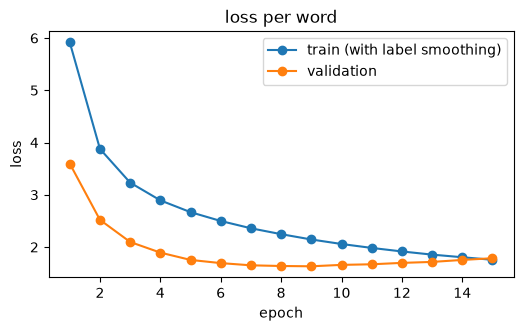

In [19]:
plt.figure(figsize=(6, 3.2))
plt.plot(range(1, EPOCHS + 1), [t for t, _ in history], marker="o", label="train (with label smoothing)")
plt.plot(range(1, EPOCHS + 1), [v for _, v in history], marker="o", label="validation")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("loss per word")
plt.show()

The training loss includes label smoothing and dropout, so it sits above the validation loss for a while. When validation loss stops falling while training loss keeps going down, the model has started to **overfit** (memorise the training sentences); that's why we kept the weights from the best validation epoch.

## 6 · Translating new sentences: greedy decoding

At test time there's no English sentence to read. The decoder **generates** one word at a time:

1. start with `<s>`
2. run the decoder, and take the scores for the *last* position: a score for every possible next word
3. pick the highest-scoring word (**greedy**), append it, and repeat
4. stop at `</s>`, or after a length limit

The encoder runs only once; the decoder runs once per generated word. Watch it on one test sentence:

In [20]:
@torch.no_grad()
def greedy_translate(sentences, max_len=60):
    model.eval()
    src = pad_sequence([torch.tensor(de_vocab.encode(s)) for s in sentences], batch_first=True, padding_value=PAD).to(device)
    src_mask = (src != PAD)[:, None, None, :]
    memory = model.encode(src, src_mask)                                     # encode once
    ys = torch.full((len(sentences), 1), BOS, device=device)                 # every translation starts with <s>
    for _ in range(max_len):
        _, tgt_mask = make_masks(src, ys)
        logits = model.decode(ys, memory, src_mask, tgt_mask)                # (B, t, vocabulary)
        next_word = logits[:, -1].argmax(-1)                                 # best next word for each sentence
        ys = torch.cat([ys, next_word[:, None]], dim=1)
        if (ys == EOS).any(dim=1).all():                                     # every sentence has finished
            break
    out = []
    for row in ys.tolist():
        row = row[1:]                                                        # drop <s>
        out.append(en_vocab.decode(row[: row.index(EOS)] if EOS in row else row))
    return out

@torch.no_grad()
def show_steps(sentence, max_len=30):
    # Greedy decoding for one sentence, printing the 3 most likely next words at every step
    model.eval()
    src = torch.tensor([de_vocab.encode(sentence)], device=device)
    src_mask = (src != PAD)[:, None, None, :]
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS]], device=device)
    for step in range(max_len):
        _, tgt_mask = make_masks(src, ys)
        probs = model.decode(ys, memory, src_mask, tgt_mask)[0, -1].softmax(-1)
        top = probs.topk(3)
        guesses = ", ".join(f"{en_vocab.itos[i]} {p:.2f}" for p, i in zip(top.values.tolist(), top.indices.tolist()))
        print(f"step {step:>2} | top 3: {guesses:<40} -> {en_vocab.itos[top.indices[0]]}")
        ys = torch.cat([ys, top.indices[:1][None]], dim=1)
        if top.indices[0] == EOS:
            break

print(test[0][0], "\n")
show_steps(test[0][0])

Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt. 

step  0 | top 3: a 0.85, man 0.04, guy 0.00               -> a
step  1 | top 3: man 0.87, guy 0.02, male 0.00            -> man
step  2 | top 3: in 0.41, with 0.28, wearing 0.14         -> in
step  3 | top 3: an 0.88, a 0.08, orange 0.00             -> an
step  4 | top 3: orange 0.96, elmo 0.00, oranges 0.00     -> orange
step  5 | top 3: hat 0.82, shirt 0.01, ski 0.00           -> hat
step  6 | top 3: <unk> 0.15, that 0.07, is 0.06           -> <unk>
step  7 | top 3: something 0.82, . 0.05, for 0.03         -> something
step  8 | top 3: . 0.84, </s> 0.03, to 0.00               -> .
step  9 | top 3: </s> 0.92, <unk> 0.00, . 0.00            -> </s>


In [21]:
for de, en in random.Random(1).sample(test, 5):
    print("DE: ", de)
    print("REF:", en)
    print("OUT:", greedy_translate([de])[0], "\n")

DE:  Ein paar Bier-Zapfhähne in einer Bar mit Weihnachtsdekoration an der Decke.
REF: A bunch of beer pull tabs at a bar with Christmas lights on the ceiling.
OUT: a couple of beer beer in a bar with the ceiling on it . 

DE:  Santa Claus wird bei einem Medienevent zu Weihnachten fotografiert.
REF: Santa Claus being photographed at a holiday media event.
OUT: <unk> <unk> is being photographed by a <unk> photo by a <unk> . 

DE:  Eine Frau in einem roten Hemd reitet auf einem weißen Pferd, das an den Bäumen entlang galoppiert.
REF: A woman in a red shirt is riding an all white horse that is galloping along the trees.
OUT: a woman in a red shirt rides a white horse down the trees . 

DE:  Eine Person sieht zum Computer auf einem Tisch mit einem Telefon und einer Schachtel.
REF: A person is looking at the computer on a desk with a phone and a box.
OUT: a person is looking at a table with a purple phone and a box on top of a box . 

DE:  Ein junges Paar sitzt auf dem Gehsteig und entspannt

## 7 · Measuring quality: BLEU

**BLEU** is the standard translation metric. For $n = 1, 2, 3, 4$ it counts how many of the output's $n$-word sequences also appear in the reference translation (each counted at most as often as in the reference), takes the geometric mean of those four precisions, and multiplies by a **brevity penalty** that punishes outputs shorter than the reference. It's computed over the whole test set and ranges from 0 to 100.

Here it's computed on lowercased, tokenized text, as in most tutorials. Papers report case-sensitive BLEU on untokenized text, which comes out a few points lower.

In [22]:
start = time.time()
hypotheses = []
for i in range(0, len(test), 128):
    hypotheses += greedy_translate([de for de, _ in test[i:i + 128]])
references = [" ".join(tokenize(en)) for _, en in test]
bleu = sacrebleu.corpus_bleu(hypotheses, [references])
print(f"test BLEU {bleu.score:.1f}  (translated {len(test):,} sentences in {time.time() - start:.0f}s)")
print("n-gram precisions (1 to 4 words):", [round(p, 1) for p in bleu.precisions], f"| brevity penalty {bleu.bp:.2f}")

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


test BLEU 36.2  (translated 1,000 sentences in 12s)
n-gram precisions (1 to 4 words): [67.0, 43.6, 29.2, 20.0] | brevity penalty 1.00


## 8 · Looking inside: attention maps

When the decoder writes an English word, which German words does it look at? We run the model once more on a sentence and its translation, and plot the **cross-attention** weights of the last decoder layer: rows are English words, columns are German words, and dark means "looked here". Averaged over the heads, it often looks like a word alignment: *Hund* ↔ *dog*. After the average, each head is shown separately, since different heads often look at different things.

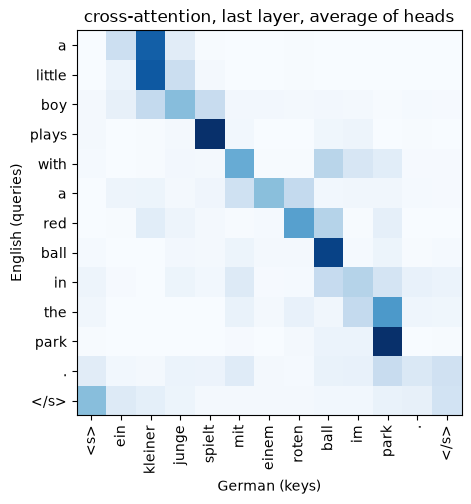

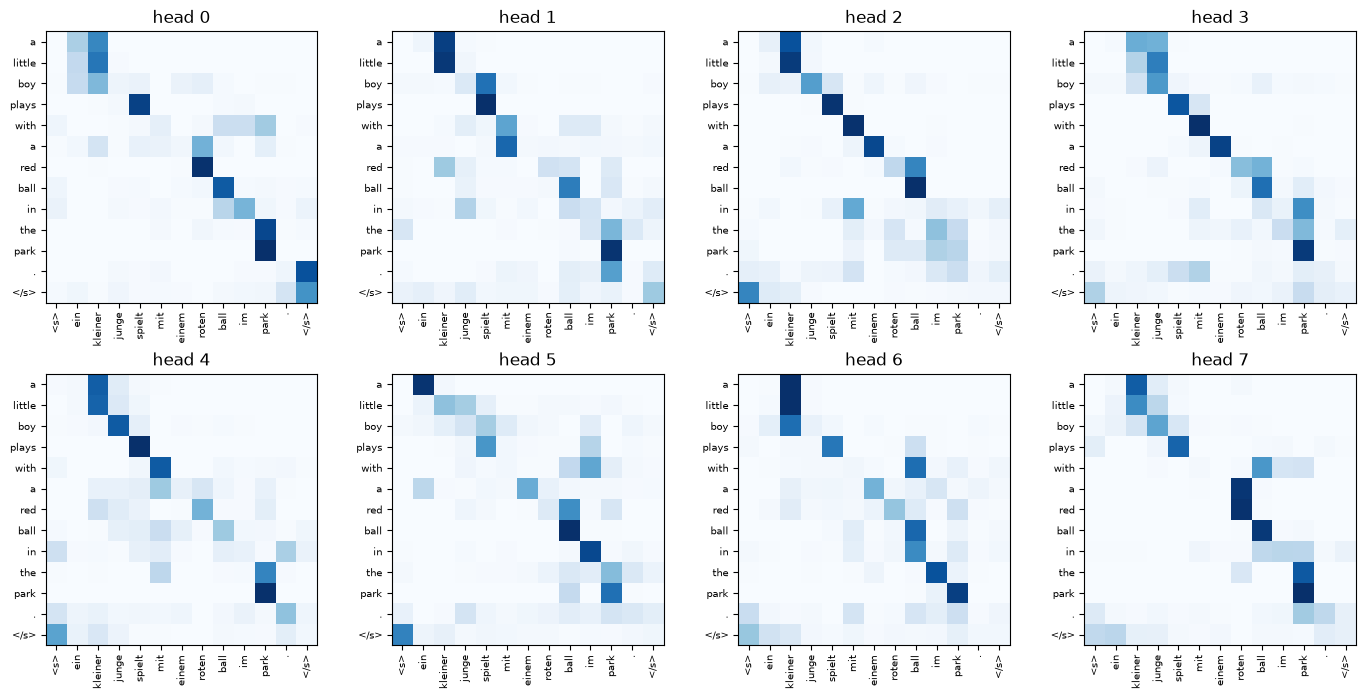

In [23]:
@torch.no_grad()
def cross_attention(sentence):
    model.eval()
    translation = greedy_translate([sentence])[0]
    src = torch.tensor([de_vocab.encode(sentence)], device=device)
    tgt = torch.tensor([en_vocab.encode(translation)], device=device)
    model(src, tgt[:, :-1])                                          # one pass, so the layers store their weights
    weights = model.decoder[-1].cross_attn.weights[0].cpu()          # (heads, English words, German words)
    rows = [en_vocab.itos[i] for i in tgt[0, 1:].tolist()]           # the word each row is predicting
    cols = [de_vocab.itos[i] for i in src[0].tolist()]
    return weights, rows, cols

weights, rows, cols = cross_attention("Ein kleiner Junge spielt mit einem roten Ball im Park.")
plt.figure(figsize=(6, 5))
plt.imshow(weights.mean(0), cmap="Blues")
plt.xticks(range(len(cols)), cols, rotation=90); plt.yticks(range(len(rows)), rows)
plt.xlabel("German (keys)"); plt.ylabel("English (queries)"); plt.title("cross-attention, last layer, average of heads")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for head, ax in enumerate(axes.flat):
    ax.imshow(weights[head], cmap="Blues")
    ax.set_xticks(range(len(cols)), cols, rotation=90, fontsize=7); ax.set_yticks(range(len(rows)), rows, fontsize=7)
    ax.set_title(f"head {head}")
plt.tight_layout(); plt.show()

## 9 · Recap

| The paper says | Where it is here |
|---|---|
| encoder and decoder stacks of $N$ layers, with residual connections and LayerNorm | `EncoderLayer`, `DecoderLayer`, `Transformer` (4.6–4.8) |
| scaled dot-product attention, $\text{softmax}(QK^\top/\sqrt{d_k})V$ | `attention` (4.3) |
| multi-head attention, $h = 8$ | `MultiHeadAttention` (4.5) |
| masking out padding and future positions | `make_masks` (4.4) |
| position-wise feed-forward network | `self.ff` in each layer (4.6) |
| embeddings × $\sqrt{d_\text{model}}$, sinusoidal positional encoding | `Transformer.embed`, `positional_encoding` (4.1–4.2) |
| Adam ($\beta_2 = 0.98$), warm-up, label smoothing 0.1, dropout 0.1 | section 5 |
| weight tying between embeddings and the output layer | not used here (separate vocabularies) |
| beam search | not used here: greedy decoding (section 6) |

**Experiments to try** (change a setting, re-run from the top, compare the BLEU):

1. `N_LAYERS = 1` and `N_LAYERS = 6`: how much does depth help on this small dataset?
2. `N_HEADS = 1`: one big head instead of eight small ones.
3. Remove `+ self.pe[: ids.size(1)]` in `Transformer.embed`: the model loses word order. What happens to the translations?
4. Replace `causal` with all `True` in `make_masks`: the training loss drops much lower, but the translations fall apart. Why?
5. Set `label_smoothing=0.0`: compare validation perplexity and BLEU.

**Next in the series:** Part 2 drops the encoder and keeps only the decoder, which gives a GPT: a model trained to predict the next character of Shakespeare.